DL

1. Data Aquisition/ Collect
2. Data Preprocessing
3. Feature Extraction
4. Model Building and Training
5. Model Evaluation


In [74]:
import numpy as np
import pandas as pd
import keras as keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam

In [75]:
data = pd.read_csv("/content/BHARTIARTL.NS (1).csv")

In [76]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [77]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-12-20,839.750000,839.750000,822.000000,828.950012,825.159668,2828863
1,2022-12-21,833.000000,833.049988,812.349976,814.000000,810.278015,5079337
2,2022-12-22,819.000000,824.700012,809.500000,816.599976,812.866089,3626834
3,2022-12-23,814.000000,817.950012,805.000000,808.650024,804.952515,2804496
4,2022-12-26,805.049988,815.200012,801.150024,811.000000,807.291748,6023206


In [78]:
# preprocess data
#data = pd.read_csv("/content/drive/MyDrive/Jesiliya/BHARTIARTL.NS (1).csv")
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')
data = data.sort_index()

In [79]:
# Additional Features
data['MA_10'] = data['Close'].rolling(window=10).mean()
data['Volume_Scaled'] = MinMaxScaler().fit_transform(data['Volume'].values.reshape(-1, 1))

In [80]:
# Combine features
features = ['Close', 'MA_10', 'Volume_Scaled']
data = data[features].dropna()

In [81]:
data.head()

,Close,MA_10,Volume_Scaled
Date,,,
2023-01-02,813.500000,813.814996,0.034364
2023-01-03,817.599976,812.679993,0.036281
2023-01-04,811.799988,812.459992,0.062739
2023-01-05,807.099976,811.509992,0.111895
2023-01-06,796.000000,810.244989,0.067585


*Tanh* - (-1,1)
*Sigmoid* - (0,1)

In [82]:
data.count()

,0
Close,238
MA_10,238
Volume_Scaled,238


In [83]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [84]:
data.head()

,Close,MA_10,Volume_Scaled
Date,,,
2023-01-02,813.500000,813.814996,0.034364
2023-01-03,817.599976,812.679993,0.036281
2023-01-04,811.799988,812.459992,0.062739
2023-01-05,807.099976,811.509992,0.111895
2023-01-06,796.000000,810.244989,0.067585


In [85]:
# Create sequences for time series prediction
def create_sequences(data, sequence_length):
    sequences = []
    targets = []

    for i in range(len(data) - sequence_length):
        seq = data[i:i + sequence_length]
        target = data[i + sequence_length]
        sequences.append(seq)
        targets.append(target)

    return np.array(sequences), np.array(targets)

In [86]:
# Define the sequence length
sequence_length = 20

In [87]:
# Create sequences and targets
sequences, targets = create_sequences(data_scaled, sequence_length)

In [88]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(sequences, targets, test_size=0.2, random_state=42)

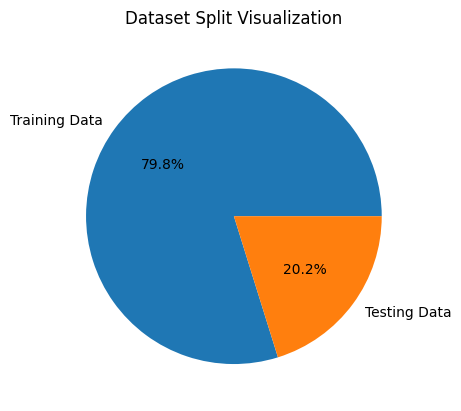

In [89]:
sizes = [len(X_train), len(X_test)]
labels = ['Training Data', 'Testing Data']

# Plot
plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Dataset Split Visualization")
plt.show()

In [90]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=50, activation='relu'))
model.add(Dense(units=len(features)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [91]:
# Compile the model with Mean Absolute Error as an additional metric
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

In [92]:
# Custom Callback to check for NaN during training
class CustomCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if np.isnan(logs['loss']) or np.isnan(logs['val_loss']):
            print(f'Epoch {epoch + 1}: NaN loss encountered.')
            self.model.stop_training = True

In [93]:
# Train the model with the custom callback
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[CustomCallback()])

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.1472 - mae: 0.2816 - val_loss: 0.1565 - val_mae: 0.2983
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1043 - mae: 0.2284 - val_loss: 0.1021 - val_mae: 0.2356
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0646 - mae: 0.1798 - val_loss: 0.0130 - val_mae: 0.0862
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0150 - mae: 0.0871 - val_loss: 0.0091 - val_mae: 0.0679
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0082 - mae: 0.0634 - val_loss: 0.0101 - val_mae: 0.0756
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0124 - mae: 0.0781 - val_loss: 0.0058 - val_mae: 0.0586
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0062 - mae: 0.0579 - val_loss: 0.0056 - val_mae: 0.0590
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0063 - mae: 0.0577 - val_loss: 0.0047 - val_mae: 0.0524
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0060 - mae: 0.0566 -

In [94]:
# Make predictions
predicted_prices_scaled = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices_scaled)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 386ms/step


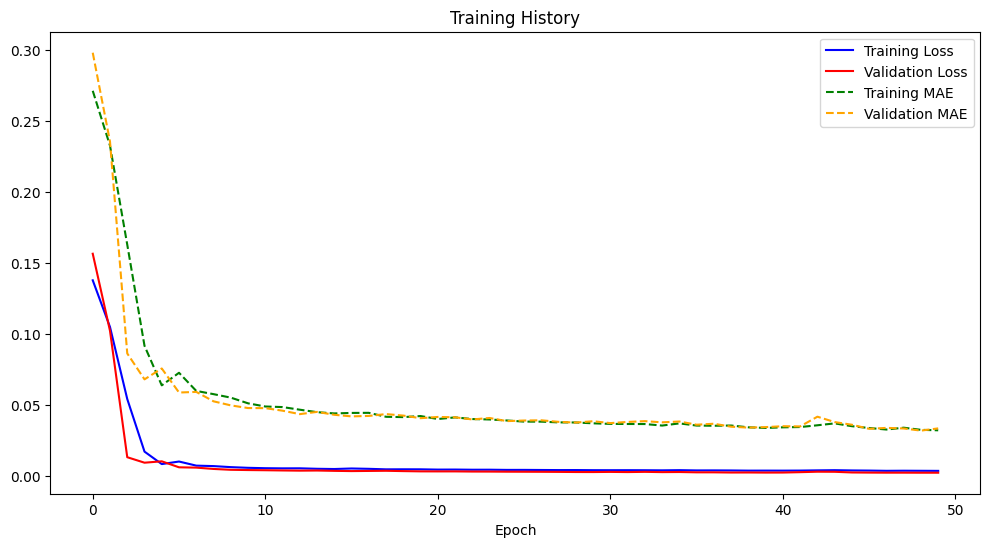

In [95]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.plot(history.history['mae'], label='Training MAE', linestyle='dashed', color='green')
plt.plot(history.history['val_mae'], label='Validation MAE', linestyle='dashed', color='orange')
plt.title('Training History')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [96]:
#sample try no.12
# Load and preprocess the new dataset
new_data = pd.read_csv("/content/BHARTIARTL.NS (1).csv")
new_data['Date'] = pd.to_datetime(new_data['Date'])
new_data = new_data.set_index('Date')
new_data = new_data.sort_index()

# Additional Features
new_data['MA_10'] = data['Close'].rolling(window=10).mean()

#new_data['Volume_Scaled'] = MinMaxScaler().fit_transform(data['Volume'].values.reshape(-1, 1))
new_data['Volume_Scaled'] = MinMaxScaler().fit_transform(new_data['Volume'].values.reshape(-1, 1))

# Combine features
new_features = ['Close', 'MA_10', 'Volume_Scaled']
new_data = data[new_features].dropna()

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
new_data_scaled = scaler.fit_transform(new_data)

# Normalize the new data using the same scaler used for training data
#new_data_scaled = scaler.transform(new_data)

# Create sequences and targets for the new data
new_sequences, new_targets = create_sequences(new_data_scaled, sequence_length)

# Make predictions on the new data
new_predicted_prices_scaled = model.predict(new_sequences)
new_predicted_prices = scaler.inverse_transform(new_predicted_prices_scaled)

# Evaluate the model
mse, mae = model.evaluate(new_sequences, new_targets)
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0028 - mae: 0.0306
Mean Squared Error: 0.003032744862139225
Mean Absolute Error: 0.03253984823822975


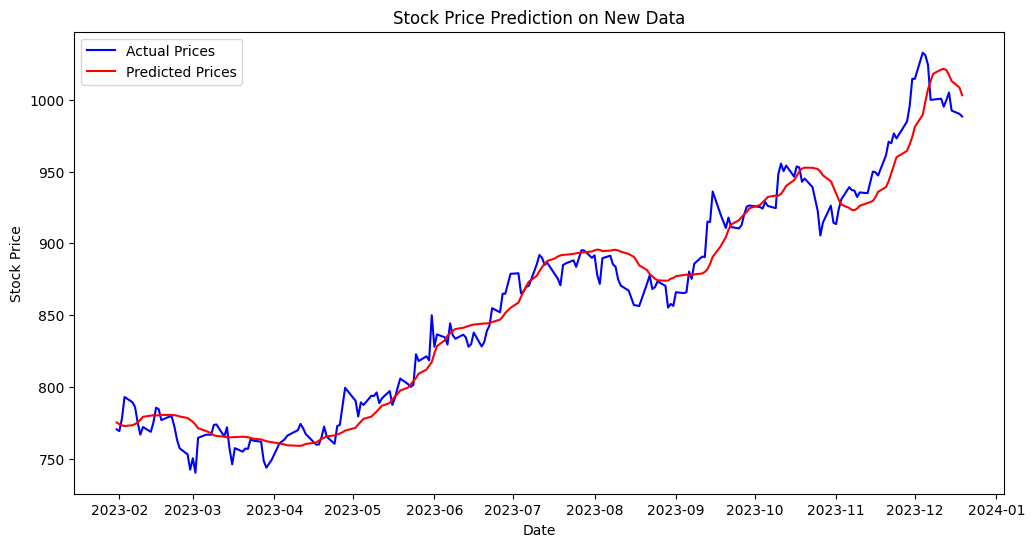

In [97]:
# Plot the predictions
plt.figure(figsize=(12, 6))
plt.plot(new_data.index[-len(new_predicted_prices):], new_data['Close'].values[-len(new_predicted_prices):], label='Actual Prices', color='blue')
plt.plot(new_data.index[-len(new_predicted_prices):], new_predicted_prices[:, 0], label='Predicted Prices', color='red')
plt.title('Stock Price Prediction on New Data')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [98]:
# Create a confusion matrix for the predictions
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_new = mean_squared_error(new_targets, new_predicted_prices_scaled)
mae_new = mean_absolute_error(new_targets, new_predicted_prices_scaled)

print(f'Mean Squared Error on New Data: {mse_new}')
print(f'Mean Absolute Error on New Data: {mae_new}')

Mean Squared Error on New Data: 0.003032744777038097
Mean Absolute Error on New Data: 0.03253985107414068


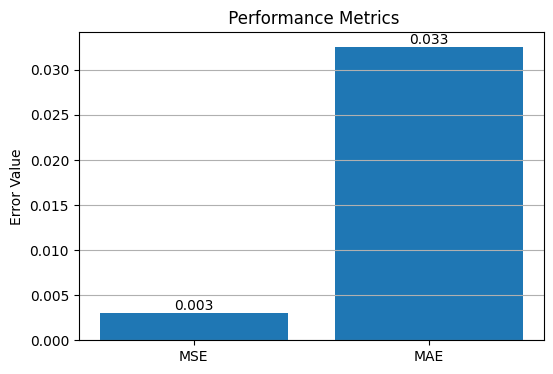

In [99]:
import matplotlib.pyplot as plt

metrics = ['MSE', 'MAE']
values = [mse, mae]

plt.figure(figsize=(6,4))
bars = plt.bar(metrics, values)

plt.title(' Performance Metrics')
plt.ylabel('Error Value')

# Display value on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             round(yval, 3),
             ha='center', va='bottom')

plt.grid(axis='y')
plt.show()

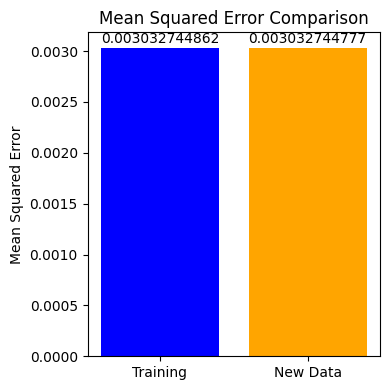

In [100]:
# Define a function to add values above the bars
def autolabel(bars, values):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.00015,
                 f'{value:.12f}', ha='center', va='top', fontsize=10)

# Plot the Mean Squared Error
plt.figure(figsize=(4, 4))
bars_mse = plt.bar(['Training', 'New Data'], [mse, mse_new], color=['blue', 'orange'])
plt.title('Mean Squared Error Comparison')
plt.ylabel('Mean Squared Error')
autolabel(bars_mse, [mse, mse_new])

plt.tight_layout()
plt.show()

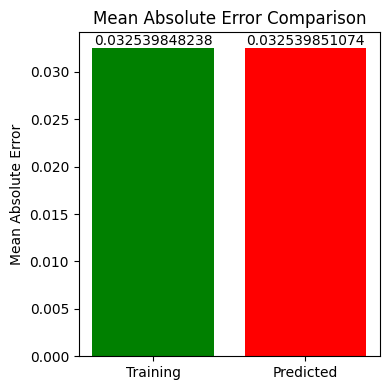

In [101]:
# Define a function to add values above the bars
def autolabel(bars, values):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.0015,
                 f'{value:.12f}', ha='center', va='top', fontsize=10)

# Plot the Mean Absolute Error
plt.figure(figsize=(4, 4))
bars_mae = plt.bar(['Training', 'Predicted'], [mae, mae_new], color=['green', 'red'])
plt.title('Mean Absolute Error Comparison')
plt.ylabel('Mean Absolute Error')
autolabel(bars_mae, [mae, mae_new])

plt.tight_layout()
plt.show()